In [13]:
%load_ext autoreload
%autoreload 2
from notebook import *
# if get something about NUMEXPR_MAX_THREADS being set incorrectly, don't worry.  It's not a problem.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Experience Intel's "Performance Cores" and "Efficient Cores"

Intel's 13th generation processors also incorporate the idea of "Single ISA, Heterogeneous Architectures" or say "big.Little" architecture. In Linux system, the CPU id of p-cores comes first and then the e-cores. 

In [24]:
! lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      28
  On-line CPU(s) list:       0-27
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Core(TM) i7-14700K
    CPU family:              6
    Model:                   183
    Thread(s) per core:      2
    Core(s) per socket:      20
    Socket(s):               1
    Stepping:                1
    CPU(s) scaling MHz:      33%
    CPU max MHz:             5600.0000
    CPU min MHz:             800.0000
    BogoMIPS:                6835.20
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush dts acpi mmx fxsr sse 
                             sse2 ss ht tm pbe syscall nx pdpe1gb rdtscp lm cons
                             tant_tsc art arch_perfmon pebs bts rep_go

In [32]:
# Who are P-cores?
!  cat /sys/devices/cpu_core/cpus

0-15


In [34]:
# Who are E-cores?
! cat /sys/devices/cpu_atom/cpus

16-27


We can use taskset to see what the performance look like!

## Random from OS

In [15]:
hist_size = 1000000000
! make fiddle.exe; make C_OPTS="-O3" build/histogram.so
! ./fiddle.exe -lib ./build/histogram.so --header 'config,' --preamble 'all,' --detail -f run_private2_histogram -s {hist_size} --threads 1 2 3 4 -o histogram_private2_locks.csv

make: 'fiddle.exe' is up to date.
make: 'build/histogram.so' is up to date.
registering function: run_unthreaded_histogram
registering function: run_threaded_histogram
registering function: run_fine_locks_histogram
registering function: run_private_histogram
registering function: run_private2_histogram
registering function: run_openmp_histogram
registering function: run_openmp_private_histogram
Dynamically registering run_fine_locks_histogram
Dynamically registering run_openmp_histogram
Dynamically registering run_openmp_private_histogram
Dynamically registering run_private2_histogram
Dynamically registering run_private_histogram
Dynamically registering run_threaded_histogram
Dynamically registering run_unthreaded_histogram
Execution started
sh: 1: /usr/sbin/changefreq: not found
sh: 1: /usr/sbin/changefreq: not found
Execution completed


,config,function,threads,size,arg1,arg2,arg3,IC,CPI,ET,L1_dcache_misses,L1_dcache_miss_rate,Cycles,speedup,Total IC,Total cache misses
0,all,run_private2_histogram,1,1000000000,1,1,1,38025650533,0.320911,2.185224,6320300,0.000263,12202864978,1.000000,38025650533,6320300
1,all,run_private2_histogram,2,1000000000,1,1,1,38031798667,0.594968,2.067419,64749555,0.002697,22627687465,1.056982,76063597334,129499110
2,all,run_private2_histogram,3,1000000000,1,1,1,37696185466,0.564381,1.526069,87473053,0.003675,21274992309,1.431930,113088556398,262419159
3,all,run_private2_histogram,4,1000000000,1,1,1,38028409360,0.656661,1.309834,113992252,0.004748,24971772358,1.668321,152113637440,455969008


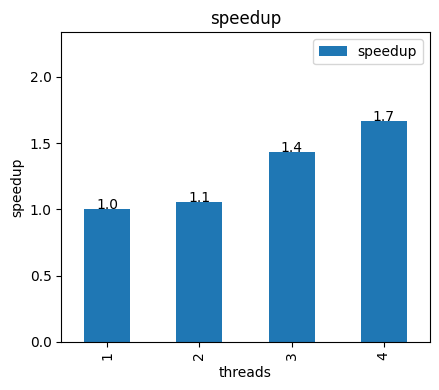

In [16]:
hist_data = render_csv("histogram_private2_locks.csv", columns=["config"]+hist_columns+["Cycles"])
#hist_data["ET"] = hist_data["ET"]/hist_data["thread"].apply(lambda x: 1 if x == 0 else x)
hist_data["speedup"] = hist_data.iloc[0]["ET"]/hist_data["ET"]
hist_data["Total IC"] = hist_data["IC"]*hist_data["threads"]
hist_data["Total cache misses"] = hist_data["L1_dcache_misses"]*hist_data["threads"]
display(hist_data)
plotPEBar(df=hist_data, what=[("threads", "speedup"), ])


## P-cores only

In [17]:
hist_size = 1000000000
! taskset -c 0,2,4,6,8,10,12,14 ./fiddle.exe -lib ./build/histogram.so --detail --header 'config,' --preamble 'pcores_only,' -f run_private2_histogram -s {hist_size} --threads 1 2 3 4 -o histogram_private2_locks_pcores_only.csv

registering function: run_unthreaded_histogram
registering function: run_threaded_histogram
registering function: run_fine_locks_histogram
registering function: run_private_histogram
registering function: run_private2_histogram
registering function: run_openmp_histogram
registering function: run_openmp_private_histogram
Dynamically registering run_fine_locks_histogram
Dynamically registering run_openmp_histogram
Dynamically registering run_openmp_private_histogram
Dynamically registering run_private2_histogram
Dynamically registering run_private_histogram
Dynamically registering run_threaded_histogram
Dynamically registering run_unthreaded_histogram
Execution started
sh: 1: /usr/sbin/changefreq: not found
sh: 1: /usr/sbin/changefreq: not found
Execution completed


,config,function,threads,size,arg1,arg2,arg3,IC,CPI,ET,L1_dcache_misses,L1_dcache_miss_rate,Cycles,speedup,Total IC,Total cache misses
0,all,run_private2_histogram,1,1000000000,1,1,1,38025650533,0.320911,2.185224,6320300,0.000263,12202864978,1.000000,38025650533,6320300
1,all,run_private2_histogram,2,1000000000,1,1,1,38031798667,0.594968,2.067419,64749555,0.002697,22627687465,1.056982,76063597334,129499110
2,all,run_private2_histogram,3,1000000000,1,1,1,37696185466,0.564381,1.526069,87473053,0.003675,21274992309,1.431930,113088556398,262419159
3,all,run_private2_histogram,4,1000000000,1,1,1,38028409360,0.656661,1.309834,113992252,0.004748,24971772358,1.668321,152113637440,455969008
0,pcores_only,run_private2_histogram,1,1000000000,1,1,1,38025662763,0.324629,2.213142,15436071,0.000643,12344221357,0.987385,38025662763,15436071
1,pcores_only,run_private2_histogram,2,1000000000,1,1,1,38029254254,0.527836,1.912626,51227612,0.002133,20073226297,1.142526,76058508508,102455224
2,pcores_only,run_private2_histogram,3,1000000000,1,1,1,38031745369,0.573398,1.481643,76070230,0.003168,21807325766,1.474865,114095236107,228210690
3,pcores_only,run_private2_histogram,4,1000000000,1,1,1,38029838505,0.639168,1.281771,88754443,0.003696,24307452365,1.704847,152119354020,355017772


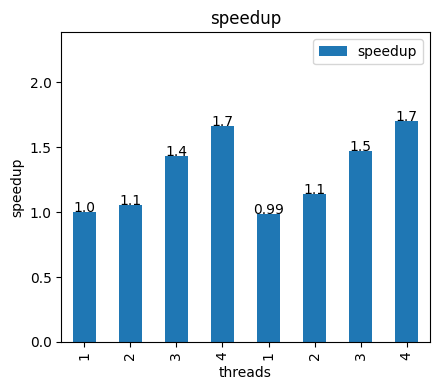

In [18]:
hist_size = 1000000000
hist_data = render_csv(["histogram_private2_locks.csv", "histogram_private2_locks_pcores_only.csv"], columns=["config"]+hist_columns+["Cycles"])
#hist_data["ET"] = hist_data["ET"]/hist_data["thread"].apply(lambda x: 1 if x == 0 else x)
hist_data["speedup"] = hist_data.iloc[0]["ET"]/hist_data["ET"]
hist_data["Total IC"] = hist_data["IC"]*hist_data["threads"]
hist_data["Total cache misses"] = hist_data["L1_dcache_misses"]*hist_data["threads"]
display(hist_data)
#plotPE(df=hist_data, lines=True, what=[("threads", "speedup"), ])
plotPEBar(df=hist_data, what=[("threads", "speedup")])

## E-cores only

In [19]:
hist_size = 1000000000
! cd ~/courses/CS203/demo/bigLittle;  taskset -c 16,17,18,19,20,21,22,23 ./fiddle.exe -lib ./build/histogram.so -M 3600 --detail  --header 'config,' --preamble 'ecores_only,'  -f run_private2_histogram -s {hist_size} --threads 1 2 3 4 -o histogram_private2_locks_ecores_only.csv

registering function: run_unthreaded_histogram
registering function: run_threaded_histogram
registering function: run_fine_locks_histogram
registering function: run_private_histogram
registering function: run_private2_histogram
registering function: run_openmp_histogram
registering function: run_openmp_private_histogram
Dynamically registering run_fine_locks_histogram
Dynamically registering run_openmp_histogram
Dynamically registering run_openmp_private_histogram
Dynamically registering run_private2_histogram
Dynamically registering run_private_histogram
Dynamically registering run_threaded_histogram
Dynamically registering run_unthreaded_histogram
Execution started
sh: 1: /usr/sbin/changefreq: not found
sh: 1: /usr/sbin/changefreq: not found
Execution completed


,config,function,threads,size,arg1,arg2,arg3,IC,CPI,ET,L1_dcache_misses,L1_dcache_miss_rate,Cycles,speedup,Total IC,Total cache misses
0,all,run_private2_histogram,1,1000000000,1,1,1,38025650533,0.320911,2.185224,6320300,0.000263,12202864978,1.000000,38025650533,6320300
1,all,run_private2_histogram,2,1000000000,1,1,1,38031798667,0.594968,2.067419,64749555,0.002697,22627687465,1.056982,76063597334,129499110
2,all,run_private2_histogram,3,1000000000,1,1,1,37696185466,0.564381,1.526069,87473053,0.003675,21274992309,1.431930,113088556398,262419159
3,all,run_private2_histogram,4,1000000000,1,1,1,38028409360,0.656661,1.309834,113992252,0.004748,24971772358,1.668321,152113637440,455969008
0,pcores_only,run_private2_histogram,1,1000000000,1,1,1,38025662763,0.324629,2.213142,15436071,0.000643,12344221357,0.987385,38025662763,15436071
1,pcores_only,run_private2_histogram,2,1000000000,1,1,1,38029254254,0.527836,1.912626,51227612,0.002133,20073226297,1.142526,76058508508,102455224
2,pcores_only,run_private2_histogram,3,1000000000,1,1,1,38031745369,0.573398,1.481643,76070230,0.003168,21807325766,1.474865,114095236107,228210690
3,pcores_only,run_private2_histogram,4,1000000000,1,1,1,38029838505,0.639168,1.281771,88754443,0.003696,24307452365,1.704847,152119354020,355017772
0,ecores_only,run_private2_histogram,1,1000000000,1,1,1,0,NaN,2.395921,0,NaN,0,0.912060,0,0
1,ecores_only,run_private2_histogram,2,1000000000,1,1,1,0,NaN,2.595569,0,NaN,0,0.841906,0,0


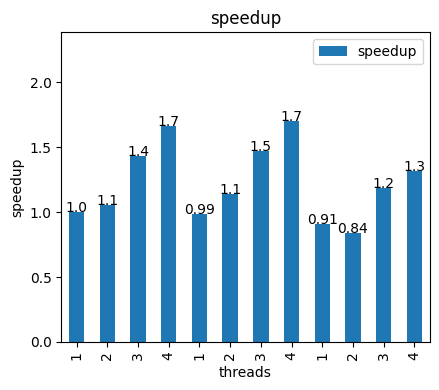

In [20]:
hist_data = render_csv(["histogram_private2_locks.csv", "histogram_private2_locks_pcores_only.csv", "histogram_private2_locks_ecores_only.csv"], columns=["config"]+hist_columns+["Cycles"])
#hist_data["ET"] = hist_data["ET"]/hist_data["thread"].apply(lambda x: 1 if x == 0 else x)
hist_data["speedup"] = hist_data.iloc[0]["ET"]/hist_data["ET"]
hist_data["Total IC"] = hist_data["IC"]*hist_data["threads"]
hist_data["Total cache misses"] = hist_data["L1_dcache_misses"]*hist_data["threads"]
display(hist_data)
#plotPE(df=hist_data, lines=True, what=[("threads", "speedup"), ])
plotPEBar(df=hist_data, what=[("threads", "speedup")])

## Half and half

In [21]:
! taskset -c 12,14,16,17 ./fiddle.exe -lib ./build/histogram.so -M 3600 --detail --header 'config,' --preamble 'half_and_half,' -f run_private2_histogram -s {hist_size} --threads 1 2 3 4 -o histogram_private2_locks_both.csv

registering function: run_unthreaded_histogram
registering function: run_threaded_histogram
registering function: run_fine_locks_histogram
registering function: run_private_histogram
registering function: run_private2_histogram
registering function: run_openmp_histogram
registering function: run_openmp_private_histogram
Dynamically registering run_fine_locks_histogram
Dynamically registering run_openmp_histogram
Dynamically registering run_openmp_private_histogram
Dynamically registering run_private2_histogram
Dynamically registering run_private_histogram
Dynamically registering run_threaded_histogram
Dynamically registering run_unthreaded_histogram
Execution started
sh: 1: /usr/sbin/changefreq: not found
sh: 1: /usr/sbin/changefreq: not found
Execution completed


,config,function,threads,size,arg1,arg2,arg3,IC,CPI,ET,L1_dcache_misses,L1_dcache_miss_rate,Cycles,speedup,Total IC,Total cache misses
0,half_and_half,run_private2_histogram,1,1000000000,1,1,1,38017123914,0.324735,2.249992,15842741,0.000660,12345489845,1.000000,38017123914,15842741
1,half_and_half,run_private2_histogram,2,1000000000,1,1,1,37495968631,0.558621,1.944039,151926212,0.006417,20946027593,1.157380,74991937262,303852424
2,half_and_half,run_private2_histogram,3,1000000000,1,1,1,29505545874,0.529584,1.545064,74224791,0.003984,15625653116,1.456245,88516637622,222674373
3,half_and_half,run_private2_histogram,4,1000000000,1,1,1,24276932114,0.592336,1.315774,78669941,0.005132,14380110430,1.710014,97107728456,314679764


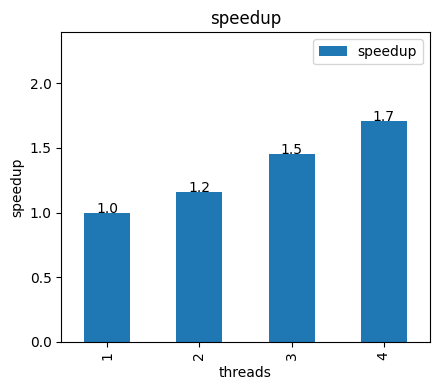

In [22]:
hist_data = render_csv("histogram_private2_locks_both.csv", columns=["config"]+hist_columns+["Cycles"])
#hist_data["ET"] = hist_data["ET"]/hist_data["thread"].apply(lambda x: 1 if x == 0 else x)
hist_data["speedup"] = hist_data.iloc[0]["ET"]/hist_data["ET"]
hist_data["Total IC"] = hist_data["IC"]*hist_data["threads"]
hist_data["Total cache misses"] = hist_data["L1_dcache_misses"]*hist_data["threads"]
display(hist_data)
plotPEBar(df=hist_data, what=[("threads", "speedup"), ])

,function,threads,size,arg1,arg2,arg3,IC,CPI,ET,L1_dcache_misses,L1_dcache_miss_rate,Cycles,speedup,Total IC,Total cache misses
0,run_private2_histogram,1,1000000000,1,1,1,38017123914,0.324735,2.249992,15842741,0.000660,12345489845,1.000000,38017123914,15842741
1,run_private2_histogram,2,1000000000,1,1,1,37495968631,0.558621,1.944039,151926212,0.006417,20946027593,1.157380,74991937262,303852424
2,run_private2_histogram,3,1000000000,1,1,1,29505545874,0.529584,1.545064,74224791,0.003984,15625653116,1.456245,88516637622,222674373
3,run_private2_histogram,4,1000000000,1,1,1,24276932114,0.592336,1.315774,78669941,0.005132,14380110430,1.710014,97107728456,314679764
0,run_private2_histogram,1,1000000000,1,1,1,38025662763,0.324629,2.213142,15436071,0.000643,12344221357,1.016651,38025662763,15436071
1,run_private2_histogram,2,1000000000,1,1,1,38029254254,0.527836,1.912626,51227612,0.002133,20073226297,1.176389,76058508508,102455224
2,run_private2_histogram,3,1000000000,1,1,1,38031745369,0.573398,1.481643,76070230,0.003168,21807325766,1.518579,114095236107,228210690
3,run_private2_histogram,4,1000000000,1,1,1,38029838505,0.639168,1.281771,88754443,0.003696,24307452365,1.755378,152119354020,355017772
0,run_private2_histogram,1,1000000000,1,1,1,0,NaN,2.395921,0,NaN,0,0.939093,0,0
1,run_private2_histogram,2,1000000000,1,1,1,0,NaN,2.595569,0,NaN,0,0.866859,0,0


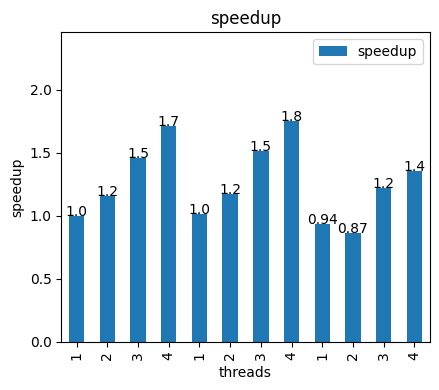

In [23]:
hist_data = render_csv(["histogram_private2_locks_both.csv", "histogram_private2_locks_pcores_only.csv", "histogram_private2_locks_ecores_only.csv"], columns=hist_columns+["Cycles"])
#hist_data["ET"] = hist_data["ET"]/hist_data["thread"].apply(lambda x: 1 if x == 0 else x)
hist_data["speedup"] = hist_data.iloc[0]["ET"]/hist_data["ET"]
hist_data["Total IC"] = hist_data["IC"]*hist_data["threads"]
hist_data["Total cache misses"] = hist_data["L1_dcache_misses"]*hist_data["threads"]
display(hist_data)
#plotPE(df=hist_data, lines=True, what=[("threads", "speedup"), ])
plotPEBar(df=hist_data, what=[("threads", "speedup")])